# Laboratorio 4 — Análisis de Datos GeoEspaciales
## Cianobacteria en los lagos de Atitlán y Amatitlán (Sentinel-2)

**CC3084 – Data Science | Semestre II 2026**

Integrantes: 
- Daniel Oswaldo Juárez Herrera
- Humberto Alexander de la Cruz
- Nicolle Alexandra Gordillo

---

## Configuración

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from scipy import ndimage
import matplotlib.pyplot as plt
import json

RAIZ = Path.cwd()
DIR_RAW     = RAIZ / "datos" / "raw"        # lo que baja 01_descarga.py
DIR_INDICES = RAIZ / "datos" / "indices"    # índices calculados (se generan aquí)
DIR_GEOJSON = RAIZ / "datos" / "geojson"    # opcional: límite oficial del lago
DIR_RES     = RAIZ / "resultados"
DIR_FIG     = DIR_RES / "figuras"
for d in (DIR_INDICES, DIR_GEOJSON, DIR_RES, DIR_FIG):
    d.mkdir(parents=True, exist_ok=True)

NOMBRE = {"atitlan": "Lago de Atitlán", "amatitlan": "Lago de Amatitlán"}
COLOR  = {"atitlan": "#1b6ca8", "amatitlan": "#c0392b"}

# Fechas oficiales con su nubosidad y satélite (tabla del enunciado)
ESCENAS = {
    "atitlan": [("2025-01-18",0.02,"S2B"), ("2025-04-13",0.54,"S2C"), ("2025-05-13",4.37,"S2C"),
                ("2025-07-17",3.57,"S2A"), ("2025-11-21",3.15,"S2A"), ("2025-12-29",3.17,"S2C"),
                ("2026-02-12",0.04,"S2B"), ("2026-03-24",3.17,"S2B"), ("2026-04-13",0.01,"S2B"),
                ("2026-04-28",4.96,"S2C"), ("2026-07-22",4.02,"S2B")],
    "amatitlan":[("2025-01-28",0.06,"S2B"), ("2025-04-15",0.09,"S2A"), ("2025-04-28",1.03,"S2B"),
                ("2025-11-24",0.50,"S2B"), ("2026-01-08",0.77,"S2C"), ("2026-02-02",0.39,"S2B"),
                ("2026-02-07",0.02,"S2C"), ("2026-03-29",0.01,"S2C"), ("2026-04-13",0.09,"S2B"),
                ("2026-04-28",4.96,"S2C"), ("2026-06-19",13.00,"S2A")],
}
LAGOS = list(ESCENAS)
BANDAS = ["B02","B03","B04","B05","B07","B08","B8A","B11","B12","SCL"]

# --- Umbrales 
SCL_INVALIDAS   = {0, 1, 3, 8, 9, 10}  # sin dato, saturado, sombra, nube, cirros
UMBRAL_FAI      = 0.08     # nata flotante (umbral del script original)
CHLA_ALTO       = 10.0     # µg/L, nivel de alerta 1 de la OMS para uso recreativo
CHLA_SEVERO     = 25.0     # µg/L, condición hipereutrófica
FRACCION_AGUA   = 0.5      # un píxel es "lago" si fue agua en >=X% de las fechas.
                           # Solo se usa si NO hay geojson. Si la máscara sale mucho
                           # más chica que el lago real, bajarlo a 0.2 (ver validación).
CHLA_MAX        = 500.0    # µg/L, tope del rango de calibración del modelo CyanoLakes
COBERTURA_MIN   = 40.0     # % del lago sin nube para considerar la fecha confiable

# Superficie oficial de cada lago, para validar la máscara (km²)
AREA_REAL = {"atitlan": 130.1, "amatitlan": 15.2}

MESES_LLUVIA = {5,6,7,8,9,10}
estacion = lambda f: "Lluviosa" if int(f[5:7]) in MESES_LLUVIA else "Seca"

CSV = DIR_RES / "estadisticas_por_fecha.csv"
ruta_raw     = lambda lago, f: DIR_RAW / lago / f"{lago}_{f}.tif"
ruta_indices = lambda lago, f: DIR_INDICES / lago / f"{lago}_{f}_indices.tif"

## Funciones base

### El índice de cianobacteria

Se usa el custom script oficial de Sentinel Hub **"Cyanobacteria Chlorophyll-a NDCI"**
(Kravitz & Matthews, 2020 — CyanoLakes):
<https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/>

El script hace tres cosas, que aquí se separan como capas de datos en vez de mezclarse
en una paleta de colores:

| Componente | Fórmula | Bandas |
|---|---|---|
| Máscara de agua (Mohor Gartner) | combinación de MNDWI, NDWI, AWEI, NDVI, DBSI | B02 B03 B04 B08 B11 B12 |
| Floating Algal Index (Hu, 2009) | `B07 − B04 − (B8A − B04)·(783−665)/(865−665)` | B04 B07 B8A |
| NDCI (Mishra & Mishra, 2012) | `(B05 − B04)/(B05 + B04)` | B04 B05 |
| Chl-a (calibración CyanoLakes) | `826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071` | — |

El **NDCI** es el índice de cianobacteria propiamente dicho (adimensional);
la **Chl-a en µg/L** es su traducción a una magnitud interpretable para ambientalistas.

In [2]:
def _div(a, b):
    "División segura: 0/0 -> NaN, sin warnings."
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.divide(a, b)
    r[~np.isfinite(r)] = np.nan
    return r.astype(np.float32)

def norm(x, y):
    "Índice normalizado genérico (x-y)/(x+y)."
    return _div(x - y, x + y)

def mascara_agua_wbi(b02, b03, b04, b08, b11, b12):
    "Detección de cuerpos de agua del script CyanoLakes (técnica de Mohor Gartner)."
    r, g, b, nir, swir1, swir2 = b04, b03, b02, b08, b11, b12
    ndvi_       = norm(nir, r)
    mndwi       = norm(g, swir1)
    ndwi_       = norm(g, nir)
    ndwi_leaves = norm(nir, swir1)
    aweish  = b + 2.5*g - 1.5*(nir + swir1) - 0.25*swir2
    aweinsh = 4*(g - swir1) - (0.25*nir + 2.75*swir1)
    dbsi    = norm(swir1, g) - ndvi_
    agua = ((mndwi > 0.42) | (ndwi_ > 0.40) | (aweinsh > 0.1879)
            | (aweish > 0.1112) | (ndvi_ < -0.2) | (ndwi_leaves > 1))
    agua = np.nan_to_num(agua, nan=False).astype(bool)
    # filtra zonas urbanas y suelo desnudo
    no_agua = np.nan_to_num((aweinsh <= -0.03) | (dbsi > 0), nan=False).astype(bool)
    return agua & ~no_agua

def calcular_indices(b):
    "Recibe un dict de bandas en reflectancia 0-1 y devuelve todas las capas derivadas."
    # Control de calidad: en agua oscura la reflectancia corregida (L2A) puede salir
    # negativa o casi cero. Ahí el denominador del índice normalizado se acerca a cero
    # y el NDCI se dispara fuera de su rango físico [-1, 1], generando falsas
    # floraciones. Esos píxeles se descartan antes de calcular nada.
    ok = (b["B04"] > 0) & (b["B05"] > 0)
    ndci = np.clip(np.where(ok, norm(b["B05"], b["B04"]), np.nan), -1, 1)
    chla = np.clip(826.57*ndci**3 - 176.43*ndci**2 + 19*ndci + 4.071, 0, CHLA_MAX)
    fai  = b["B07"] - b["B04"] - (b["B8A"] - b["B04"])*(783-665)/(865-665)
    return {
        "ndci": ndci.astype(np.float32),
        "chla": chla.astype(np.float32),
        "fai":  fai.astype(np.float32),
        "nata": np.nan_to_num(fai > UMBRAL_FAI, nan=False).astype(bool),
        "ndci_ok": ok,
        "ndvi": norm(b["B08"], b["B04"]),
        "ndwi": norm(b["B03"], b["B08"]),
        "agua": mascara_agua_wbi(b["B02"], b["B03"], b["B04"], b["B08"], b["B11"], b["B12"]),
    }

### Lectura de imágenes y máscara del lago

**Por qué la máscara del lago se congela.** Una floración densa hace que el agua se
comporte ópticamente como vegetación: el NDWI baja y el NDVI sube. Si se recalculara
la máscara de agua en cada fecha, justo los píxeles con floración quedarían fuera del
análisis y se subestimaría el fenómeno. Por eso un píxel pertenece al lago si fue agua
en al menos el 50 % de las fechas válidas, y esa máscara se usa igual en todas las
fechas: así el número de píxeles del lago es constante y los porcentajes entre fechas
son comparables.

In [3]:
def leer_escena(lago, fecha):
    "Devuelve (bandas en reflectancia 0-1, máscara de píxeles válidos, perfil rasterio)."
    ruta = ruta_raw(lago, fecha)
    if not ruta.exists():
        return None, None, None
    with rasterio.open(ruta) as src:
        datos, perfil = src.read().astype(np.float32), src.profile.copy()
    b = {n: datos[i] for i, n in enumerate(BANDAS)}

    scl = b.pop("SCL")
    valido = ~np.isin(np.rint(scl).astype(np.int16), list(SCL_INVALIDAS))

    # openEO entrega enteros 0-10000; se detecta y escala automáticamente
    m = b["B04"][np.isfinite(b["B04"])]
    if m.size and np.nanpercentile(m, 99) > 1.5:
        b = {k: v/10000.0 for k, v in b.items()}

    sin_dato = np.all(np.stack(list(b.values())) == 0, axis=0)  # borde de la órbita
    return b, valido & ~sin_dato, perfil

def mascara_lago(lago, fechas, perfil):
    "Límite del lago: geojson si existe, si no consenso temporal de agua."
    gj = DIR_GEOJSON / f"{lago}.geojson"
    if gj.exists():
        d = json.loads(gj.read_text(encoding="utf-8"))
        geoms = [f["geometry"] for f in d.get("features", [])] or [d["geometry"]]
        m = geometry_mask(geoms, out_shape=(perfil["height"], perfil["width"]),
                          transform=perfil["transform"], invert=True)
        print(f"  máscara desde geojson: {m.sum():,} píxeles")
        return m

    acum_agua = acum_val = None
    for f in fechas:
        b, val, _ = leer_escena(lago, f)
        if b is None:
            continue
        agua = mascara_agua_wbi(b["B02"], b["B03"], b["B04"], b["B08"], b["B11"], b["B12"]) & val
        if acum_agua is None:
            acum_agua = np.zeros(agua.shape, np.int16); acum_val = np.zeros(agua.shape, np.int16)
        acum_agua += agua; acum_val += val

    frec = np.divide(acum_agua, np.maximum(acum_val, 1), dtype=np.float32)
    m = (frec >= FRACCION_AGUA) & (acum_val >= 3)
    m = ndimage.binary_opening(m, structure=np.ones((3,3)))   # quita píxeles sueltos
    m = ndimage.binary_fill_holes(m)                          # rellena huecos con nata
    et, n = ndimage.label(m)
    if n > 1:                                                 # se queda con el lago principal
        m = et == (int(np.argmax(ndimage.sum(m, et, range(1, n+1)))) + 1)
    print(f"  máscara estable: {m.sum():,} píxeles de agua")
    return m

def area_km2(mascara, perfil):
    "Superficie de la máscara en km², para comprobar que corresponde al lago real."
    tr = perfil["transform"]
    lat = tr.f + tr.e * perfil["height"] / 2          # latitud del centro
    dx = abs(tr.a) * 111320 * np.cos(np.radians(lat))  # metros por píxel (este-oeste)
    dy = abs(tr.e) * 110540                            # metros por píxel (norte-sur)
    return float(mascara.sum()) * dx * dy / 1e6

def guardar_tif(ruta, arrays, nombres, perfil):
    p = perfil.copy()
    p.update(driver="GTiff", dtype="float32", count=len(arrays), compress="deflate", nodata=np.nan)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(ruta, "w", **p) as dst:
        for i, (a, n) in enumerate(zip(arrays, nombres), 1):
            dst.write(a.astype(np.float32), i); dst.set_band_description(i, n)

In [4]:
import urllib.request, urllib.parse, json, time

CONSULTAS = {"atitlan": "Lago de Atitlán, Guatemala",
             "amatitlan": "Lago de Amatitlán, Guatemala"}

def bajar_geojson(lago, consulta):
    url = ("https://nominatim.openstreetmap.org/search?"
           + urllib.parse.urlencode({"q": consulta, "format": "json",
                                     "polygon_geojson": 1, "limit": 5}))
    req = urllib.request.Request(url, headers={"User-Agent": "UVG-CC3084-Lab4"})
    with urllib.request.urlopen(req, timeout=30) as r:
        res = json.load(r)
    poly = [x for x in res
            if x.get("geojson", {}).get("type") in ("Polygon", "MultiPolygon")]
    if not poly:
        print(f"{lago}: no se encontró polígono"); return
    mejor = poly[0]
    fc = {"type": "FeatureCollection",
          "features": [{"type": "Feature",
                        "properties": {"name": mejor.get("display_name"),
                                       "fuente": "OpenStreetMap (ODbL)"},
                        "geometry": mejor["geojson"]}]}
    (DIR_GEOJSON / f"{lago}.geojson").write_text(json.dumps(fc), encoding="utf-8")
    print(f"{lago}: {mejor['geojson']['type']} guardado — "
          f"{mejor.get('display_name','')[:60]}")

for lago, consulta in CONSULTAS.items():
    bajar_geojson(lago, consulta)
    time.sleep(1)   # Nominatim pide máximo 1 consulta por segundo

atitlan: Polygon guardado — Lago de Atitlán, San Pedro La Laguna, Sololá, 07013, Guatema


amatitlan: Polygon guardado — Lago de Amatitlán, Villa Canales, Departamento de Guatemala,


---
# Ejercicio 3 — Índice de cianobacteria, NDVI y NDWI

Se aplica el script de cianobacteria a las 11 fechas de cada lago y se guardan
dos productos: un GeoTIFF por fecha con todas las capas (lo usan las secciones
de análisis espacial) y una tabla resumen con una fila por lago-fecha.

In [5]:
CAPAS = ["ndci","chla","fai","ndvi","ndwi","agua","valido","nata"]

def procesar(lago):
    print(f"=== {NOMBRE[lago]} ===")
    escenas = [e for e in ESCENAS[lago] if ruta_raw(lago, e[0]).exists()]
    faltan  = [e[0] for e in ESCENAS[lago] if not ruta_raw(lago, e[0]).exists()]
    if faltan: print(f"  AVISO: faltan {len(faltan)} fechas por descargar: {', '.join(faltan)}")
    if not escenas: print("  No hay imágenes. Corra antes 01_descarga.py"); return []

    _, _, perfil = leer_escena(lago, escenas[0][0])
    lago_m = mascara_lago(lago, [e[0] for e in escenas], perfil)
    area, esperada = area_km2(lago_m, perfil), AREA_REAL[lago]
    print(f"  superficie detectada: {area:.1f} km² (real ≈ {esperada} km², "
          f"{100*area/esperada:.0f}%)")
    if area < 0.8 * esperada:
        print("  *** AVISO: la máscara deja fuera parte del lago. Use el geojson del "
              "curso (datos/geojson/<lago>.geojson) o baje FRACCION_AGUA a 0.2 ***")
    guardar_tif(DIR_INDICES / f"mascara_{lago}.tif", [lago_m.astype(np.float32)],
                ["mascara_lago"], perfil)

    filas = []
    for fecha, nub, sat in escenas:
        b, val, perfil = leer_escena(lago, fecha)
        if b["B04"].shape != lago_m.shape:
            print(f"  [ERROR] {fecha}: dimensiones distintas, vuelva a descargarla"); continue
        c = calcular_indices(b)
        n_lago = int(lago_m.sum())
        cob = 100 * int((lago_m & val).sum()) / max(n_lago, 1)   # cobertura sin nubes
        sel = lago_m & val & c["ndci_ok"]   # además, índice físicamente válido
        n_val = int(sel.sum())
        descartados = int((lago_m & val & ~c["ndci_ok"]).sum())

        fila = dict(lago=lago, fecha=fecha, anio=int(fecha[:4]), mes=int(fecha[5:7]),
                    estacion=estacion(fecha), satelite=sat, nubosidad_escena_pct=nub,
                    pixeles_lago=n_lago, pixeles_validos=n_val,
                    cobertura_valida_pct=round(cob, 2),
                    pct_descartado_ndci=round(100*descartados/max(n_lago, 1), 2),
                    confiable=(cob >= COBERTURA_MIN) and (100*descartados/max(n_lago,1) < 20))
        if n_val:
            ndci_v, chla_v = c["ndci"][sel], c["chla"][sel]
            fila.update(
                ndci_media=float(np.nanmean(ndci_v)), ndci_mediana=float(np.nanmedian(ndci_v)),
                ndci_p90=float(np.nanpercentile(ndci_v, 90)),
                chla_media=float(np.nanmean(chla_v)), chla_mediana=float(np.nanmedian(chla_v)),
                chla_p90=float(np.nanpercentile(chla_v, 90)),
                ndvi_media=float(np.nanmean(c["ndvi"][sel])),
                ndwi_media=float(np.nanmean(c["ndwi"][sel])),
                fai_media=float(np.nanmean(c["fai"][sel])),
                pct_chla_alto=100*float(np.nanmean(chla_v >= CHLA_ALTO)),
                pct_chla_severo=100*float(np.nanmean(chla_v >= CHLA_SEVERO)),
                pct_nata=100*float(np.nanmean(c["nata"][sel])))
        filas.append(fila)

        guardar_tif(ruta_indices(lago, fecha),
                    [c["ndci"], c["chla"], c["fai"], c["ndvi"], c["ndwi"],
                     c["agua"].astype(np.float32), val.astype(np.float32),
                     c["nata"].astype(np.float32)], CAPAS, perfil)
        print(f"  {fecha}: cobertura {cob:5.1f}%  NDCI {fila.get('ndci_media', np.nan):+.3f}  "
              f"Chl-a mediana {fila.get('chla_mediana', np.nan):5.1f} µg/L  "
              f"floración {fila.get('pct_chla_alto', np.nan):5.1f}% del lago  "
              f"(descartado {fila['pct_descartado_ndci']:.1f}%)")
    return filas

df = pd.DataFrame([f for lago in LAGOS for f in procesar(lago)]).sort_values(["lago","fecha"])
df.to_csv(CSV, index=False)
print(f"\nGuardado: {CSV}")
df.head()

=== Lago de Atitlán ===
  máscara desde geojson: 261,558 píxeles
  superficie detectada: 124.5 km² (real ≈ 130.1 km², 96%)


  2025-01-18: cobertura 100.0%  NDCI -0.147  Chl-a mediana   0.0 µg/L  floración  19.2% del lago  (descartado 75.5%)


  2025-04-13: cobertura 100.0%  NDCI -0.028  Chl-a mediana   3.4 µg/L  floración   1.0% del lago  (descartado 0.0%)


  2025-05-13: cobertura 100.0%  NDCI -0.012  Chl-a mediana   3.9 µg/L  floración   1.2% del lago  (descartado 0.0%)


  2025-07-17: cobertura 100.0%  NDCI +0.013  Chl-a mediana   4.3 µg/L  floración   2.3% del lago  (descartado 0.2%)


...

  2026-03-29: cobertura 100.0%  NDCI +0.255  Chl-a mediana  10.4 µg/L  floración  52.6% del lago  (descartado 0.0%)


  2026-04-13: cobertura 100.0%  NDCI +0.289  Chl-a mediana  14.2 µg/L  floración  81.4% del lago  (descartado 0.0%)


  2026-04-28: cobertura  94.9%  NDCI +0.276  Chl-a mediana  18.2 µg/L  floración  55.4% del lago  (descartado 0.0%)


  2026-06-19: cobertura 100.0%  NDCI +0.448  Chl-a mediana  59.3 µg/L  floración  95.8% del lago  (descartado 0.0%)

Guardado: C:\Users\Alex\OneDrive\Documents\Universidad\Octavo Semestre\Data Science\lab4\An-lisis-Geoespacial-y-sensores-remotos\resultados\estadisticas_por_fecha.csv


,lago,fecha,anio,mes,estacion,satelite,nubosidad_escena_pct,pixeles_lago,pixeles_validos,cobertura_valida_pct,...,ndci_p90,chla_media,chla_mediana,chla_p90,ndvi_media,ndwi_media,fai_media,pct_chla_alto,pct_chla_severo,pct_nata
11,amatitlan,2025-01-28,2025,1,Seca,S2B,0.06,31453,31447,100.0,...,0.367521,16.336000,12.361238,28.255611,-0.385445,0.583557,0.002119,64.600757,13.517983,0.457913
12,amatitlan,2025-04-15,2025,4,Seca,S2A,0.09,31453,31453,100.0,...,0.298372,8.683570,5.282250,15.989225,-0.072799,0.260133,0.003967,21.524179,4.536928,0.613614
13,amatitlan,2025-04-28,2025,4,Seca,S2B,1.03,31453,31452,100.0,...,0.385459,14.050943,6.602442,32.519501,-0.033973,0.252757,0.008575,38.706601,14.838484,0.976091
14,amatitlan,2025-11-24,2025,11,Seca,S2B,0.50,31453,31450,100.0,...,0.375615,14.433999,6.631646,30.119217,-0.356246,0.518337,0.003769,29.580286,12.047695,1.252782
15,amatitlan,2026-01-08,2026,1,Seca,S2C,0.77,31453,31446,100.0,...,0.448963,26.248211,15.985305,51.840382,-0.075616,0.334802,0.006447,77.634675,30.442664,1.618648


### 3.1 Control de calidad

Antes de interpretar nada hay que comprobar dos cosas: que la máscara corresponde
al lago real y que ningún índice quedó fuera de su rango físico. El NDCI es un
índice normalizado, así que **cualquier valor fuera de [-1, 1] indica un problema
de datos, no una floración**.

OK: todas las fechas tienen el NDCI dentro del rango físico [-1, 1].

Píxeles descartados por reflectancia negativa o nula (% del lago):


lago,amatitlan,atitlan
fecha,,
2025-01-18,NaN,75.47
2025-01-28,0.02,NaN
2025-04-13,NaN,0.00
2025-04-15,0.00,NaN
2025-04-28,0.00,NaN
2025-05-13,NaN,0.01
2025-07-17,NaN,0.17
2025-11-21,NaN,4.89
2025-11-24,0.01,NaN


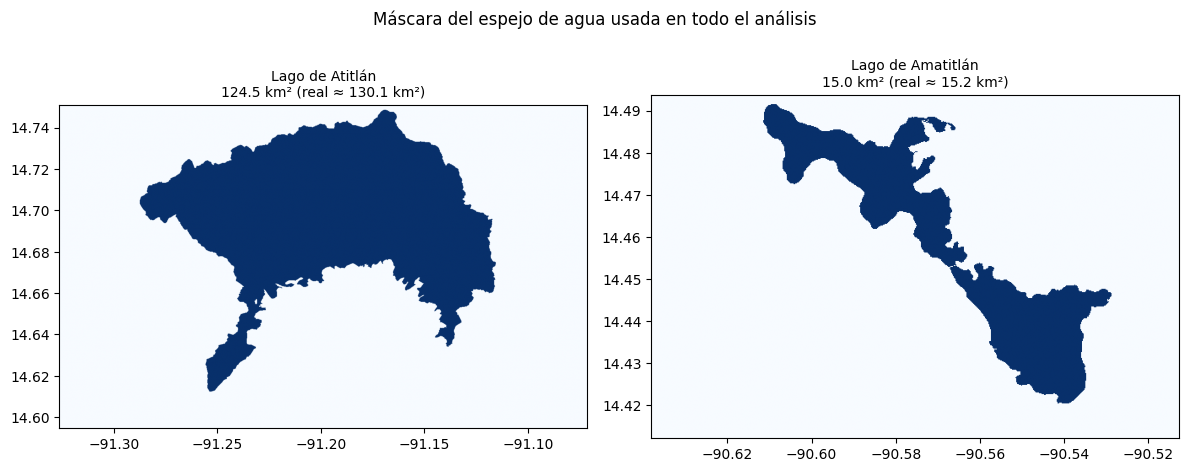

In [6]:
# --- 1. Rango físico del NDCI ---
malos = df[(df.ndci_p90.abs() > 1) | (df.ndci_media.abs() > 1)]
if len(malos):
    print("PROBLEMA: hay fechas con NDCI fuera de [-1, 1]:")
    display(malos[["lago","fecha","ndci_media","ndci_p90"]])
else:
    print("OK: todas las fechas tienen el NDCI dentro del rango físico [-1, 1].")

# --- 2. Píxeles descartados por reflectancia inválida ---
print("\nPíxeles descartados por reflectancia negativa o nula (% del lago):")
display(df.pivot_table(index="fecha", columns="lago", values="pct_descartado_ndci"))

# --- 3. Mapa de la máscara de cada lago ---
fig, axes = plt.subplots(1, len(LAGOS), figsize=(12, 5))
for ax, lago in zip(np.atleast_1d(axes), LAGOS):
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        m, bd, perfil = s.read(1), s.bounds, s.profile
    ax.imshow(m, extent=(bd[0], bd[2], bd[1], bd[3]), origin="upper", cmap="Blues")
    ax.set_title(f"{NOMBRE[lago]}\n{area_km2(m.astype(bool), perfil):.1f} km² "
                 f"(real ≈ {AREA_REAL[lago]} km²)", fontsize=10)
fig.suptitle("Máscara del espejo de agua usada en todo el análisis")
fig.tight_layout(); fig.savefig(DIR_FIG / "mascaras_lagos.png", dpi=150); plt.show()

### 3.2 Mapa del índice generado, por lago

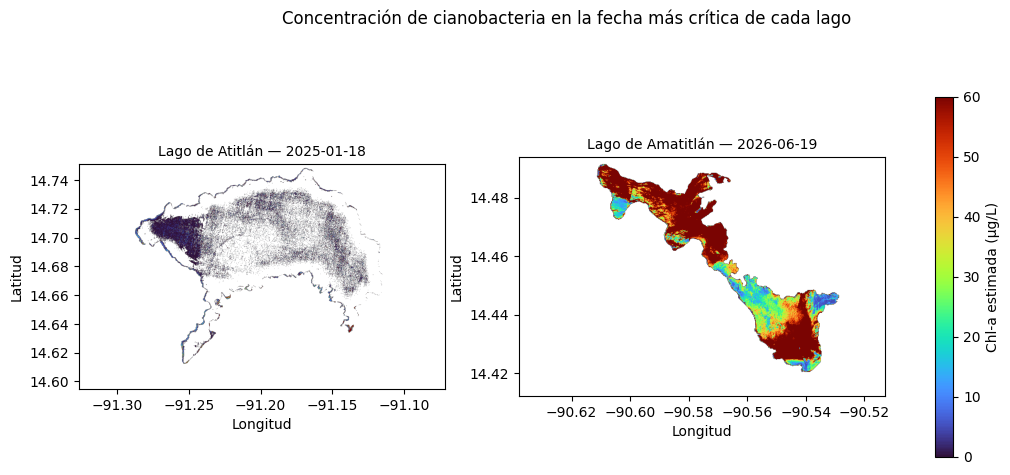

In [7]:
def mapa_chla(lago, fecha, ax=None, vmax=60):
    with rasterio.open(ruta_indices(lago, fecha)) as src:
        chla, val = src.read(2), src.read(7).astype(bool)
        izq, abajo, der, arriba = src.bounds
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as src:
        lago_m = src.read(1).astype(bool)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(np.where(lago_m & val, chla, np.nan),
                   extent=(izq, der, abajo, arriba), origin="upper",
                   cmap="turbo", vmin=0, vmax=vmax)
    ax.set_title(f"{NOMBRE[lago]} — {fecha}", fontsize=10)
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lago in zip(axes, LAGOS):
    sub = df[df.lago == lago].dropna(subset=["chla_media"])
    peor = sub.loc[sub.chla_media.idxmax(), "fecha"]
    im = mapa_chla(lago, peor, ax=ax)
fig.colorbar(im, ax=axes, label="Chl-a estimada (µg/L)", shrink=0.85)
fig.suptitle("Concentración de cianobacteria en la fecha más crítica de cada lago")
fig.savefig(DIR_FIG / "mapas_indice_por_lago.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Ejercicio 4 — Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

In [8]:
df = pd.read_csv(CSV, parse_dates=["fecha"]).sort_values(["lago","fecha"])

# Se reporta la MEDIANA de Chl-a, no la media: la conversión NDCI -> Chl-a es un
# polinomio de grado 3, así que unos pocos píxeles extremos disparan el promedio y
# lo vuelven poco representativo del lago.
tabla = df.pivot_table(index="fecha", columns="lago",
                       values=["ndci_media","chla_mediana","pct_chla_alto"]).round(3)
display(tabla)

resumen = (df[df.confiable]
           .groupby("lago")
           .agg(fechas=("fecha","count"),
                ndci_medio=("ndci_media","mean"),
                chla_mediana=("chla_mediana","median"),
                chla_p90_max=("chla_p90","max"),
                pct_lago_afectado=("pct_chla_alto","mean"),
                fechas_con_floracion=("pct_chla_alto", lambda s: int((s > 20).sum())))
           .round(2))
display(resumen)
resumen.to_csv(DIR_RES / "resumen_por_lago.csv")

chla_mediana         ndci_media         pct_chla_alto        
lago          amatitlan atitlan  amatitlan atitlan     amatitlan atitlan
fecha                                                                   
2025-01-18          NaN   0.000        NaN  -0.147           NaN  19.179
2025-01-28       12.361     NaN      0.270     NaN        64.601     NaN
2025-04-13          NaN   3.356        NaN  -0.028           NaN   1.025
2025-04-15        5.282     NaN      0.141     NaN        21.524     NaN
2025-04-28        6.602     NaN      0.195     NaN        38.707     NaN
2025-05-13          NaN   3.858        NaN  -0.012           NaN   1.160
2025-07-17          NaN   4.275        NaN   0.013           NaN   2.302
2025-11-21          NaN   2.677        NaN  -0.069           NaN   7.802
2025-11-24        6.632     NaN      0.208     NaN        29.580     NaN
2025-12-29          NaN   1.412        NaN  -0.084           NaN   3.291
2026-01-08       15.985     NaN      0.311     NaN        77.635     NaN
2026-02-02        5.371     NaN      0.137     NaN         8.142     NaN
2026-02-07        7.072     NaN      0.203     NaN        22.805     NaN
2026-02-12          NaN   3.247        NaN  -0.055           NaN   3.670
2026-03-24          NaN   3.828        NaN  -0.011           NaN   1.168
2026-03-29       10.391     NaN      0.255     NaN        52.623     NaN
2026-04-13       14.179   4.236      0.289   0.008        81.390   1.265
2026-04-28       18.180   3.608      0.276  -0.020        55.419   1.152
2026-06-19       59.271     NaN      0.448     NaN        95.825     NaN
2026-07-22          NaN   4.218        NaN   0.010           NaN   1.959

,fechas,ndci_medio,chla_mediana,chla_p90_max,pct_lago_afectado,fechas_con_floracion
lago,,,,,,
amatitlan,11,0.25,10.39,107.21,49.84,10
atitlan,10,-0.02,3.72,7.85,2.48,0


### 4.2 Evolución temporal y 4.3 picos de floración

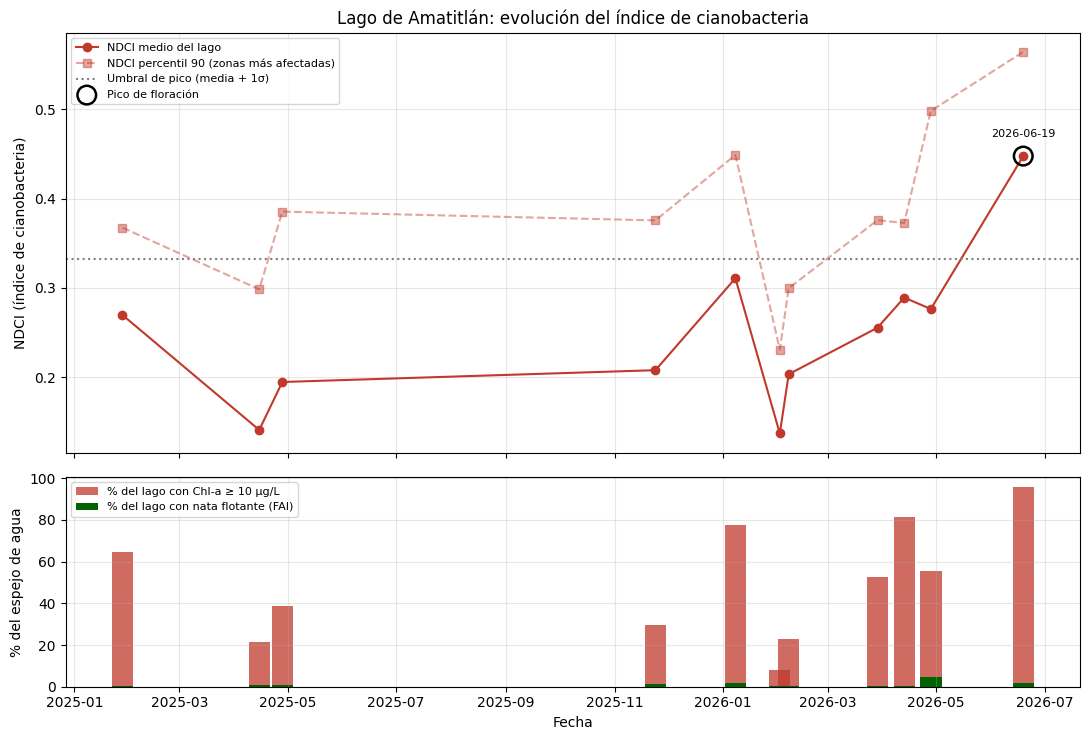

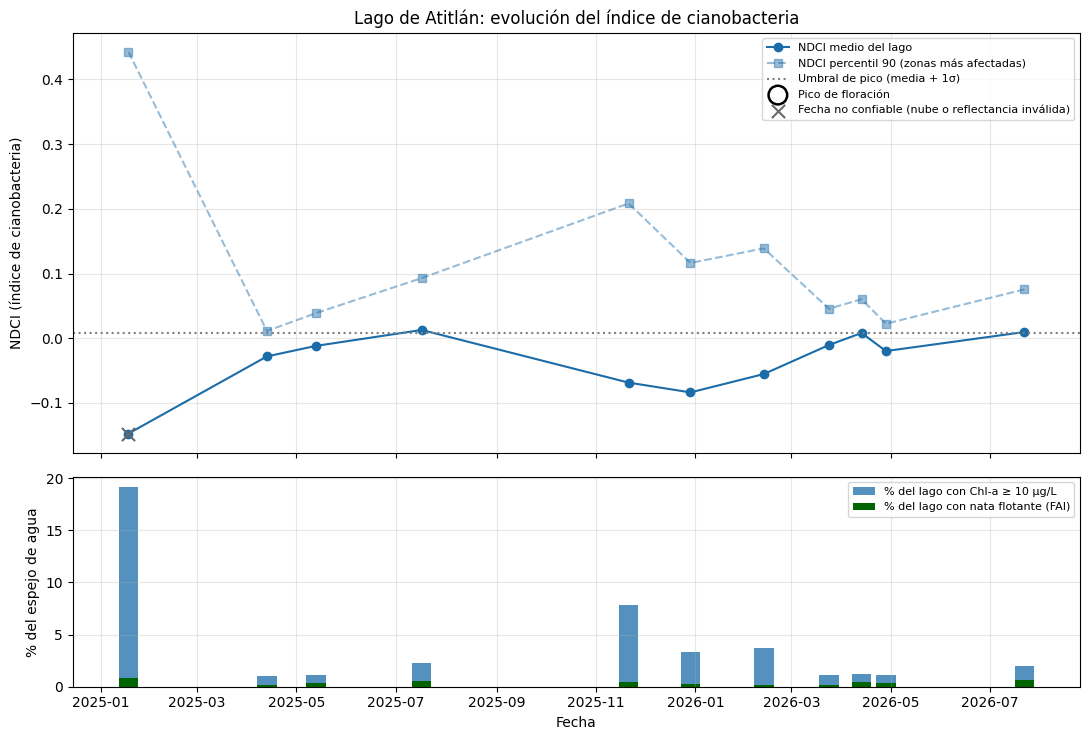

Fechas críticas detectadas:


,lago,fecha,ndci_media,chla_media,pct_chla_alto
10,amatitlan,2026-06-19,0.447697,61.507576,95.825252


In [9]:
def marcar_picos(sub, col="ndci_media", k=1.0):
    "Pico = máximo local que además supera la media del lago + 1 desviación estándar."
    conf = sub[sub.confiable]
    umbral = conf[col].mean() + k*conf[col].std(ddof=0)
    v = sub[col].to_numpy()
    local = np.array([np.isfinite(v[i])
                      and v[i] >= (v[i-1] if i else -np.inf)
                      and v[i] >= (v[i+1] if i < len(v)-1 else -np.inf)
                      for i in range(len(v))])
    sub = sub.copy()
    sub["umbral_pico"] = umbral
    sub["es_pico"] = ((sub[col] >= umbral) & local & sub.confiable
                      & (sub.pct_chla_alto >= 10))    # un pico debe afectar >=10% del lago
    return sub

df = pd.concat([marcar_picos(s) for _, s in df.groupby("lago")]).sort_values(["lago","fecha"])

for lago, sub in df.groupby("lago"):
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True,
                                 gridspec_kw={"height_ratios":[2,1]})
    a1.plot(sub.fecha, sub.ndci_media, "-o", color=COLOR[lago], label="NDCI medio del lago")
    a1.plot(sub.fecha, sub.ndci_p90, "--s", color=COLOR[lago], alpha=.45,
            label="NDCI percentil 90 (zonas más afectadas)")
    a1.axhline(sub.umbral_pico.iloc[0], color="gray", ls=":", label="Umbral de pico (media + 1σ)")
    picos = sub[sub.es_pico]
    a1.scatter(picos.fecha, picos.ndci_media, s=180, facecolors="none", edgecolors="k",
               linewidths=1.8, zorder=5, label="Pico de floración")
    for _, r in picos.iterrows():
        a1.annotate(r.fecha.strftime("%Y-%m-%d"), (r.fecha, r.ndci_media),
                    textcoords="offset points", xytext=(0,14), ha="center", fontsize=8)
    malas = sub[~sub.confiable]
    if len(malas):
        a1.scatter(malas.fecha, malas.ndci_media, marker="x", s=90, color="dimgray",
                   zorder=6, label="Fecha no confiable (nube o reflectancia inválida)")
    a1.set_ylabel("NDCI (índice de cianobacteria)"); a1.grid(alpha=.3); a1.legend(fontsize=8)
    a1.set_title(f"{NOMBRE[lago]}: evolución del índice de cianobacteria")

    a2.bar(sub.fecha, sub.pct_chla_alto, width=12, color=COLOR[lago], alpha=.75,
           label=f"% del lago con Chl-a ≥ {CHLA_ALTO:.0f} µg/L")
    a2.bar(sub.fecha, sub.pct_nata, width=12, color="darkgreen",
           label="% del lago con nata flotante (FAI)")
    a2.set_ylabel("% del espejo de agua"); a2.set_xlabel("Fecha")
    a2.grid(alpha=.3); a2.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(DIR_FIG / f"serie_temporal_{lago}.png", dpi=150)
    plt.show()

print("Fechas críticas detectadas:")
display(df[df.es_pico][["lago","fecha","ndci_media","chla_media","pct_chla_alto"]])
df.to_csv(DIR_RES / "serie_temporal_cianobacteria.csv", index=False)

### Números de referencia para la interpretación

In [10]:
# Genera los números concretos que se citan en la interpretación del 4.4.
for lago, sub in df.groupby("lago"):
    conf = sub[sub.confiable].dropna(subset=["ndci_media"])
    print(f"\n=== {NOMBRE[lago]} ===")
    print(f"NDCI medio del período: {conf.ndci_media.mean():+.3f} "
          f"(rango {conf.ndci_media.min():+.3f} a {conf.ndci_media.max():+.3f})")
    print(f"Chl-a mediana típica: {conf.chla_mediana.median():.1f} µg/L | "
          f"máximo percentil 90: {conf.chla_p90.max():.1f} µg/L")
    print(f"Superficie afectada: media {conf.pct_chla_alto.mean():.1f}%, "
          f"máxima {conf.pct_chla_alto.max():.1f}% del lago")
    print(f"Fechas con floración extendida (>20% del lago): "
          f"{int((conf.pct_chla_alto > 20).sum())} de {len(conf)}")
    print("Tres fechas más afectadas:")
    for _, r in conf.nlargest(3, "pct_chla_alto").iterrows():
        print(f"   {r.fecha.date()} — {r.pct_chla_alto:5.1f}% del lago, "
              f"Chl-a mediana {r.chla_mediana:.1f} µg/L ({r.estacion.lower()})")
    for est in ("Seca", "Lluviosa"):
        g = conf[conf.estacion == est]
        if len(g):
            print(f"   Época {est.lower():9s}: NDCI medio {g.ndci_media.mean():+.3f} "
                  f"| {g.pct_chla_alto.mean():5.1f}% del lago afectado (n={len(g)})")


=== Lago de Amatitlán ===
NDCI medio del período: +0.248 (rango +0.137 a +0.448)
Chl-a mediana típica: 10.4 µg/L | máximo percentil 90: 107.2 µg/L
Superficie afectada: media 49.8%, máxima 95.8% del lago
Fechas con floración extendida (>20% del lago): 10 de 11
Tres fechas más afectadas:
   2026-06-19 —  95.8% del lago, Chl-a mediana 59.3 µg/L (lluviosa)
   2026-04-13 —  81.4% del lago, Chl-a mediana 14.2 µg/L (seca)
   2026-01-08 —  77.6% del lago, Chl-a mediana 16.0 µg/L (seca)
   Época seca     : NDCI medio +0.228 |  45.2% del lago afectado (n=10)
   Época lluviosa : NDCI medio +0.448 |  95.8% del lago afectado (n=1)

=== Lago de Atitlán ===
NDCI medio del período: -0.025 (rango -0.084 a +0.013)
Chl-a mediana típica: 3.7 µg/L | máximo percentil 90: 7.8 µg/L
Superficie afectada: media 2.5%, máxima 7.8% del lago
Fechas con floración extendida (>20% del lago): 0 de 10
Tres fechas más afectadas:
   2025-11-21 —   7.8% del lago, Chl-a mediana 2.7 µg/L (seca)
   2026-02-12 —   3.7% del lag

### 4.4 Interpretación de los patrones temporales

- Los límites de ambos lagos provienen de OpenStreetMap (ODbL), y cubren el 96 % de la superficie oficial de Atitlán y el 99 % de la de Amatitlán. La imagen de Atitlán del 18 de enero de 2025 se excluye del análisis: perdió el 75.5 % de sus píxeles por reflectancia inválida.

**Los dos lagos se comportan de manera radicalmente distinta.** Amatitlán presenta un
índice de cianobacteria positivo en las once fechas analizadas, con media de +0.248 y un
rango de +0.137 a +0.448. Atitlán se mantiene alrededor de cero (media de −0.025) y no
registra ninguna fecha con floración extendida. No es una diferencia de grado sino de
régimen: en Amatitlán la presencia de cianobacteria es la condición permanente del lago y
lo que varía es su intensidad; en Atitlán es un fenómeno marginal.

**La evidencia más contundente son las dos fechas en que ambos lagos fueron observados el
mismo día.** El 13 de abril de 2026, la floración cubría el 81.4 % de Amatitlán y el 1.3 %
de Atitlán. El 28 de abril de 2026 las cifras fueron 55.4 % y 1.2 %. Al eliminar cualquier
diferencia de estación, clima o condiciones de captura, la comparación queda atribuida a
las características propias de cada cuerpo de agua.

**En Amatitlán la floración es crónica, no episódica.** Diez de las once fechas superan el
20 % de superficie afectada, y en promedio la mitad del lago (49.8 %) presenta niveles de
clorofila-a por encima del umbral de alerta. Incluso la fecha menos afectada de toda la
serie —el 2 de febrero de 2026— mantenía el 8.1 % del espejo de agua en esas condiciones:
nunca se observó el lago limpio. La clorofila-a mediana del lago es de 10.4 µg/L, es decir
que **la mitad del lago está habitualmente en el umbral de alerta o por encima**, y las
zonas más afectadas superan los 100 µg/L.

**Dentro del período se observa un agravamiento.** Desde febrero de 2026 la serie sube de
forma sostenida: 8.1 %, 22.8 %, 52.6 %, 81.4 %, 55.4 % y 95.8 % en junio, el máximo de todo
el registro con una mediana de 59.3 µg/L. La comparación entre meses equivalentes apunta en
la misma dirección: enero pasó de 64.6 % en 2025 a 77.6 % en 2026, y abril de 21.5 % y
38.7 % en 2025 a 81.4 % y 55.4 % en 2026. Con once observaciones no se puede afirmar una
tendencia en sentido estadístico, pero el patrón es consistente en todas las fechas
comparables y merece seguimiento.

**En Atitlán no se observan floraciones extendidas.** Ninguna de las diez fechas utilizables
supera el 20 % de superficie afectada; el valor más alto es 7.8 % (21/11/2025), seguido de
3.7 % (12/02/2026) y 3.3 % (29/12/2025). La clorofila-a mediana ronda los 3.7 µg/L, un nivel
propio de aguas poco productivas, y las zonas más afectadas apenas llegan a 7.8 µg/L. Esto
es consistente con las características del lago: es profundo, de gran volumen y con mayor
capacidad de dilución, de modo que los nutrientes que llegan se reparten en una masa de agua
mucho mayor.

**Fechas críticas.** El único episodio que el criterio estadístico marca como pico es el
**19 de junio de 2026** en Amatitlán. Por extensión de la floración, le siguen el 13 de
abril de 2026 (81.4 %) y el 8 de enero de 2026 (77.6 %). En Atitlán no se identifica ninguna
fecha crítica.

**Factores que podrían explicar lo observado.** Amatitlán es un lago somero que recibe la
descarga de la cuenca del río Villalobos, la más urbanizada del país, con aportes continuos
de aguas residuales y nutrientes desde el área metropolitana. Su poca profundidad implica
que el agua se calienta más, se estratifica con facilidad y que los nutrientes acumulados en
el sedimento vuelven a la columna de agua con relativa frecuencia. Que el lago nunca aparezca
limpio indica que el aporte de nutrientes es continuo y no depende de eventos puntuales.
Atitlán, en cambio, es profundo, de cuenca cerrada y con una presión urbana mucho menor por
unidad de volumen, lo que explica que la señal se mantenga baja de forma consistente.

**Sobre la estacionalidad no se puede concluir todavía.** De las once fechas de Amatitlán,
diez corresponden a época seca y solo una a época lluviosa —justamente el máximo de la
serie—, de modo que cualquier comparación entre estaciones estaría determinada por esa
única observación. Atitlán tiene una repartición algo mejor (siete y tres) pero sus valores
son tan bajos que no permiten distinguir un patrón.

**Limitaciones que deben acompañar cualquier conclusión.**

- Solo hay once fechas por lago en año y medio, seleccionadas por su baja nubosidad; no
  constituyen una serie continua ni permiten hablar de tendencia estadística.
- Las fechas casi no coinciden entre lagos (solo dos en común) ni se reparten de forma
  pareja entre estaciones.
- La imagen de Atitlán del 18/01/2025 fue descartada por reflectancia inválida en tres
  cuartas partes del lago.
- Los límites de los lagos provienen de OpenStreetMap, no de una fuente oficial
  guatemalteca; cubren el 96 % y el 99 % de la superficie reportada.
- El satélite solo detecta la capa superficial del agua: una población que se hunda por
  efecto del viento o de su propia flotabilidad pasa inadvertida, de modo que los mínimos no
  implican ausencia del organismo en el lago.
- La conversión del índice a clorofila-a en µg/L es empírica, calibrada con datos
  sintéticos y sin ajuste local. Sirve para comparar fechas y zonas entre sí; las cifras
  absolutas son estimaciones, no mediciones.

---
# Ejercicio 5 — Análisis espacial

Hasta ahora el índice de cianobacteria se resumió en un solo número por lago y fecha
(la media, la mediana, el percentil 90). Esa cifra oculta un hecho central para la
gestión del recurso: la floración no es uniforme dentro del lago, se concentra en
ciertas zonas y esas zonas pueden repetirse fecha tras fecha. Esta sección mapea la
distribución espacial de la cianobacteria, compara esa distribución entre fechas y
evalúa si existen áreas de acumulación persistente.

### 5.1 Distribución de la cianobacteria dentro de cada lago

Se construye un mapa interactivo (`folium`) por lago, con una capa de Chl-a estimada
superpuesta por fecha y un control para alternar entre ellas. La capa se recorta al
espejo de agua (máscara del lago) y se reduce su resolución para mantener el archivo
liviano sin perder el patrón espacial. Los mapas también se guardan como HTML
independiente en `resultados/mapas_interactivos/`, para abrirlos fuera del notebook.

In [11]:
import folium
from PIL import Image
import io, base64

df["fecha_str"] = df["fecha"].dt.strftime("%Y-%m-%d")
DIR_MAPAS = DIR_RES / "mapas_interactivos"
DIR_MAPAS.mkdir(exist_ok=True)

ANCHO_MAX_OVERLAY = 480   # px; controla el peso del HTML sin perder el patrón espacial

def _overlay_rgba(arr, mask, cmap="turbo", vmin=0, vmax=60, alpha=0.85):
    "Convierte una capa 2D en un PNG en base64, transparente fuera del lago."
    norm = np.clip(_div(arr - vmin, vmax - vmin), 0, 1)
    rgba = plt.get_cmap(cmap)(np.nan_to_num(norm, nan=0.0))
    rgba[..., 3] = np.where(mask & np.isfinite(arr), alpha, 0.0)
    im = Image.fromarray((rgba*255).astype(np.uint8))
    if im.width > ANCHO_MAX_OVERLAY:
        h = int(im.height * ANCHO_MAX_OVERLAY / im.width)
        im = im.resize((ANCHO_MAX_OVERLAY, h), Image.NEAREST)
    buf = io.BytesIO(); im.save(buf, format="PNG", optimize=True)
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

def fechas_comparacion(lago):
    "Cuatro fechas representativas: primera, última, menor y mayor floración registrada."
    sub = df[(df.lago==lago) & df.confiable].dropna(subset=["chla_mediana"]).sort_values("fecha")
    candidatas = {sub.fecha_str.iloc[0], sub.fecha_str.iloc[-1],
                  sub.loc[sub.pct_chla_alto.idxmin(), "fecha_str"],
                  sub.loc[sub.pct_chla_alto.idxmax(), "fecha_str"]}
    return sorted(candidatas)

def mapa_interactivo(lago, fechas, vmax=60):
    "Mapa folium con una capa de Chl-a por fecha (ImageOverlay) y control para alternarlas."
    idx_chla, idx_val = CAPAS.index("chla")+1, CAPAS.index("valido")+1
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        lago_m = s.read(1).astype(bool); b = s.bounds
    m = folium.Map(location=[(b.bottom+b.top)/2, (b.left+b.right)/2],
                   zoom_start=13, tiles="CartoDB positron")
    for f in fechas:
        with rasterio.open(ruta_indices(lago, f)) as s:
            chla, val = s.read(idx_chla), s.read(idx_val).astype(bool)
        uri = _overlay_rgba(chla, lago_m & val, vmax=vmax)
        folium.raster_layers.ImageOverlay(
            image=uri, bounds=[[b.bottom, b.left], [b.top, b.right]],
            name=f, opacity=1.0).add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m

mapas, fechas_sel = {}, {}
for lago in LAGOS:
    fechas_sel[lago] = fechas_comparacion(lago)
    vmax = float(df[(df.lago==lago) & df.confiable].chla_p90.quantile(0.9))
    mapas[lago] = mapa_interactivo(lago, fechas_sel[lago], vmax=vmax)
    ruta_html = DIR_MAPAS / f"{lago}_chla.html"
    mapas[lago].save(str(ruta_html))
    print(f"{NOMBRE[lago]}: mapa interactivo con {len(fechas_sel[lago])} fechas "
          f"{fechas_sel[lago]} -> {ruta_html}")

Lago de Atitlán: mapa interactivo con 3 fechas ['2025-04-13', '2025-11-21', '2026-07-22'] -> C:\Users\Alex\OneDrive\Documents\Universidad\Octavo Semestre\Data Science\lab4\An-lisis-Geoespacial-y-sensores-remotos\resultados\mapas_interactivos\atitlan_chla.html


Lago de Amatitlán: mapa interactivo con 3 fechas ['2025-01-28', '2026-02-02', '2026-06-19'] -> C:\Users\Alex\OneDrive\Documents\Universidad\Octavo Semestre\Data Science\lab4\An-lisis-Geoespacial-y-sensores-remotos\resultados\mapas_interactivos\amatitlan_chla.html



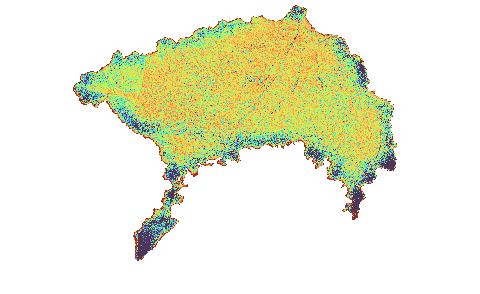
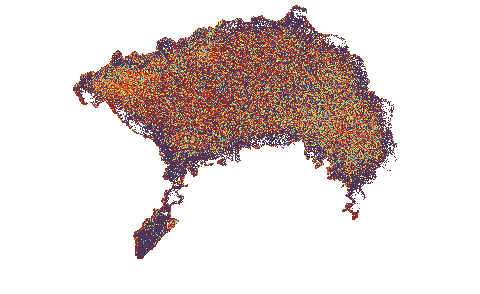
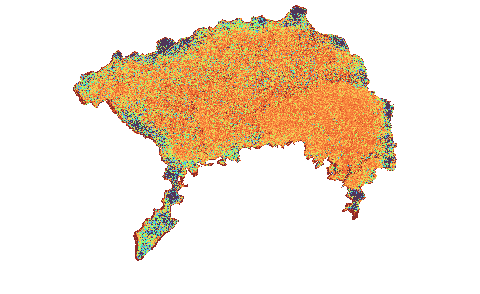

In [12]:
mapas["atitlan"]


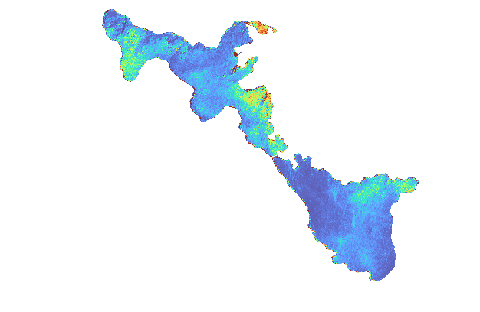
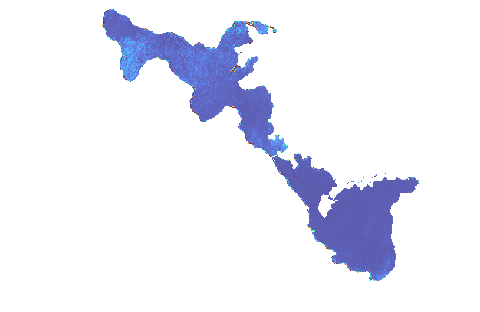
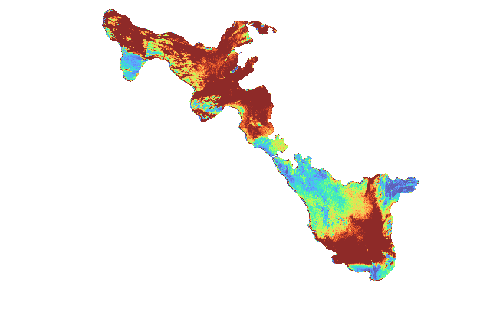

In [13]:
mapas["amatitlan"]

### 5.2 Mapas comparativos entre fechas

Se comparan, para cada lago, las mismas cuatro fechas usadas en el mapa interactivo
(primera y última observación, y las fechas de menor y mayor floración) con una
escala de color común, para que el color sea directamente comparable entre paneles.

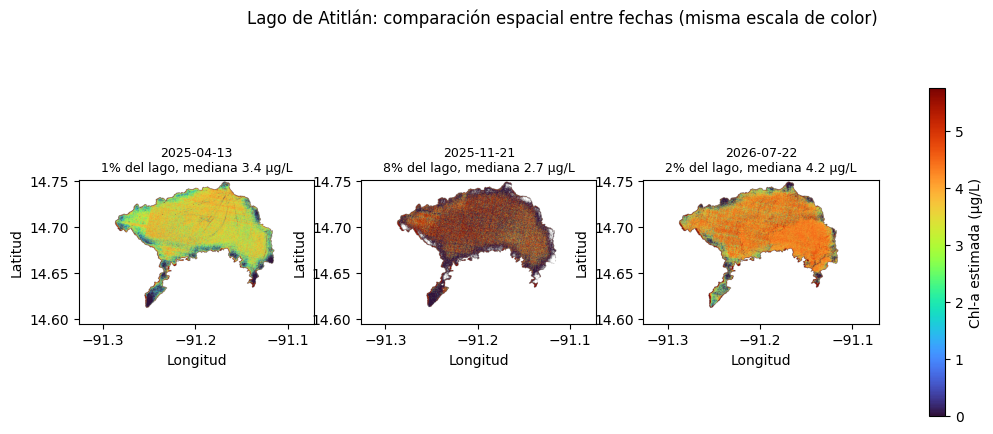

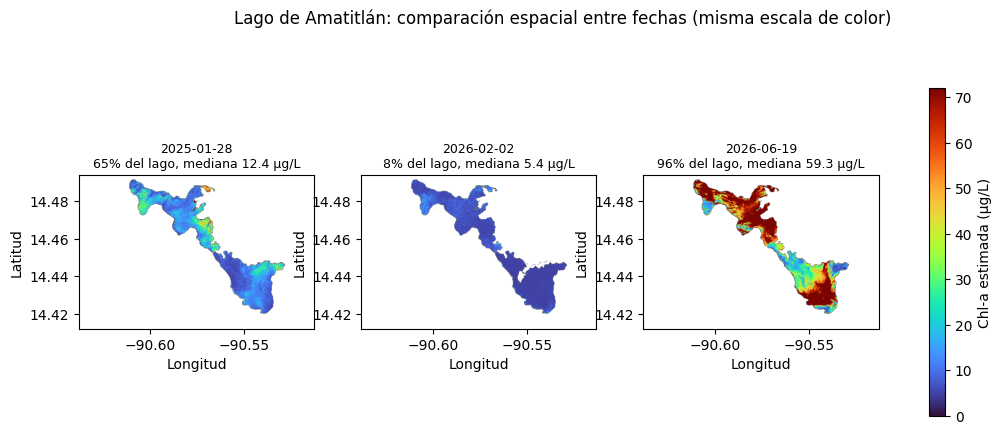

In [14]:
for lago in LAGOS:
    fechas = fechas_sel[lago]
    vmax = float(df[(df.lago==lago) & df.confiable].chla_p90.quantile(0.9))
    fig, axes = plt.subplots(1, len(fechas), figsize=(4.3*len(fechas), 5))
    for ax, f in zip(np.atleast_1d(axes), fechas):
        row = df[(df.lago==lago) & (df.fecha_str==f)].iloc[0]
        im = mapa_chla(lago, f, ax=ax, vmax=vmax)
        ax.set_title(f"{f}\n{row.pct_chla_alto:.0f}% del lago, mediana {row.chla_mediana:.1f} µg/L",
                     fontsize=9)
    fig.colorbar(im, ax=axes, label="Chl-a estimada (µg/L)", shrink=0.85)
    fig.suptitle(f"{NOMBRE[lago]}: comparación espacial entre fechas (misma escala de color)")
    fig.savefig(DIR_FIG / f"comparacion_espacial_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()

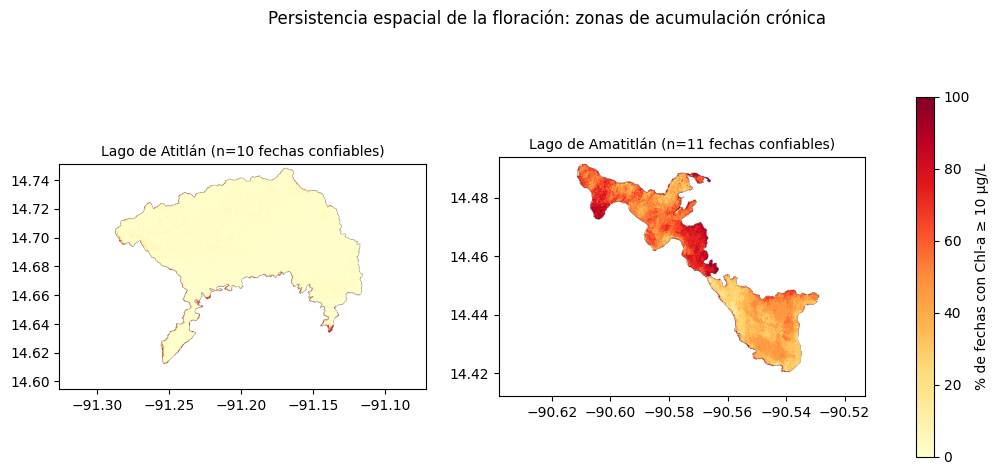

Lago de Atitlán: 1.4% del lago superó el umbral en ≥50% de las fechas observadas, 0.8% en ≥80%, y 87.7% nunca lo superó.
Lago de Amatitlán: 44.4% del lago superó el umbral en ≥50% de las fechas observadas, 9.5% en ≥80%, y 0.4% nunca lo superó.


In [15]:
def mapa_persistencia(lago, umbral=CHLA_ALTO):
    "Fracción de fechas confiables en que cada píxel superó el umbral de alerta."
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        lago_m = s.read(1).astype(bool); b = s.bounds
    fechas_conf = df[(df.lago==lago) & df.confiable].fecha_str.tolist()
    acumulado = np.zeros(lago_m.shape, np.float32)
    n_obs = np.zeros(lago_m.shape, np.float32)
    for f in fechas_conf:
        with rasterio.open(ruta_indices(lago, f)) as s:
            chla, val = s.read(2), s.read(7).astype(bool)
        sel = lago_m & val & np.isfinite(chla)
        acumulado[sel] += (chla[sel] >= umbral); n_obs[sel] += 1
    return _div(acumulado, n_obs), lago_m, n_obs, b, len(fechas_conf)

fig, axes = plt.subplots(1, len(LAGOS), figsize=(13, 5.5))
persistencia = {}
for ax, lago in zip(axes, LAGOS):
    frec, lago_m, n_obs, b, n_fechas = mapa_persistencia(lago)
    persistencia[lago] = (frec, lago_m)
    im = ax.imshow(np.where(lago_m & (n_obs > 0), frec*100, np.nan),
                   extent=(b.left, b.right, b.bottom, b.top), origin="upper",
                   cmap="YlOrRd", vmin=0, vmax=100)
    ax.set_title(f"{NOMBRE[lago]} (n={n_fechas} fechas confiables)", fontsize=10)
fig.colorbar(im, ax=axes, label=f"% de fechas con Chl-a ≥ {CHLA_ALTO:.0f} µg/L", shrink=0.85)
fig.suptitle("Persistencia espacial de la floración: zonas de acumulación crónica")
fig.savefig(DIR_FIG / "persistencia_cianobacteria.png", dpi=150, bbox_inches="tight")
plt.show()

for lago in LAGOS:
    frec, lago_m = persistencia[lago]
    validos = lago_m & np.isfinite(frec)
    print(f"{NOMBRE[lago]}: {100*np.mean(frec[validos] >= 0.5):.1f}% del lago superó el umbral "
          f"en ≥50% de las fechas observadas, {100*np.mean(frec[validos] >= 0.8):.1f}% en ≥80%, "
          f"y {100*np.mean(frec[validos] <= 0):.1f}% nunca lo superó.")

### 5.3 Interpretación de los patrones espaciales

**En Amatitlán la floración tiene una geografía fija.** El mapa de persistencia muestra
que el 44.4 % de la superficie del lago superó el umbral de alerta (Chl-a ≥ 10 µg/L) en
al menos la mitad de las fechas observadas, y un 9.5 % lo hizo en 8 de cada 10 fechas o
más; solo el 0.4 % de los píxeles nunca llegó a esas condiciones, es decir que
prácticamente todo el lago experimentó una alerta alguna vez. La zona más afectada es
consistente entre fechas y coincide con el **brazo noroeste** del lago —la porción más
cercana al área metropolitana y a la desembocadura del río Villalobos—, que aparece en
rojo oscuro (80-100 % de persistencia) incluso en la fecha con menor floración de toda la
serie (2 de febrero de 2026, con solo 8 % del lago afectado): esa franja ya mostraba
concentraciones visiblemente más altas que el resto del lago. En la fecha más crítica
(19 de junio de 2026) esa misma zona satura la escala de color, mientras que el extremo
sureste, más alejado del aporte urbano, se mantiene comparativamente más claro. Esto
apunta a una fuente de nutrientes localizada y persistente, no a un fenómeno que aparezca
de forma aleatoria en cualquier parte del lago.

**En Atitlán no hay una zona de acumulación identificable.** Solo el 1.4 % del lago superó
el umbral de alerta en la mitad o más de las fechas, y el 87.7 % de la superficie nunca lo
hizo. Los mapas comparativos muestran, en las tres fechas graficadas, una escala de color
mucho más comprimida (0–7.8 µg/L frente a 0–72 µg/L en Amatitlán) y un patrón de moteado
disperso alrededor de toda la orilla —más marcado el 21 de noviembre de 2025, la fecha con
mayor "floración" nominal (7.8 %)— que no se concentra en ninguna bahía o zona particular.
Ese patrón disperso, junto con la topografía del lago (rodeado de volcanes con paredes
abruptas que proyectan sombra sobre la orilla), sugiere que buena parte de esa señal
marginal corresponde a píxeles mixtos de borde y sombra de relieve más que a una floración
real y localizada.

**Cómo cambia la distribución entre fechas.** En Amatitlán la floración no cambia de
lugar, cambia de intensidad y de extensión: el "mapa caliente" del brazo noroeste está
presente en las tres fechas comparadas (baja, típica y alta), y lo que varía es cuánto del
resto del lago se suma a esa condición. En Atitlán no hay una progresión espacial que
describir porque no existe una señal por encima del ruido de fondo en ninguna de las
fechas analizadas.

---
# Ejercicio 6 — Correlación entre el índice de cianobacteria y NDVI/NDWI

Una floración de cianobacterias no solo eleva el NDCI: al llenarse de pigmento
fotosintético, el agua empieza a reflejar la luz de forma más parecida a la vegetación
(NDVI más alto) y menos parecida al agua libre y transparente (NDWI más bajo). Si esa
relación aparece de forma consistente en los datos, es evidencia independiente de que el
índice de cianobacteria está capturando un fenómeno físico real y no ruido del sensor.

Se calculan dos correlaciones complementarias:
- **A nivel de píxel**, usando todos los píxeles válidos del lago en todas las fechas
  confiables (cientos de miles a millones de observaciones): es la prueba más robusta,
  porque no depende de que solo haya 10-11 fechas por lago.
- **A nivel de fecha**, usando el promedio del lago en cada una de las 10-11 fechas: más
  fácil de graficar, pero con una muestra pequeña que cualquier fecha atípica puede
  distorsionar.

,lago,n_pixeles,pearson_ndci_ndvi,pearson_ndci_ndwi,spearman_ndci_ndvi,spearman_ndci_ndwi,p_ndvi,p_ndwi
0,atitlan,2484795,0.4939,-0.3722,0.4421,-0.2866,0.0,0.0
1,amatitlan,337969,0.3915,-0.1791,0.3865,-0.1223,0.0,0.0


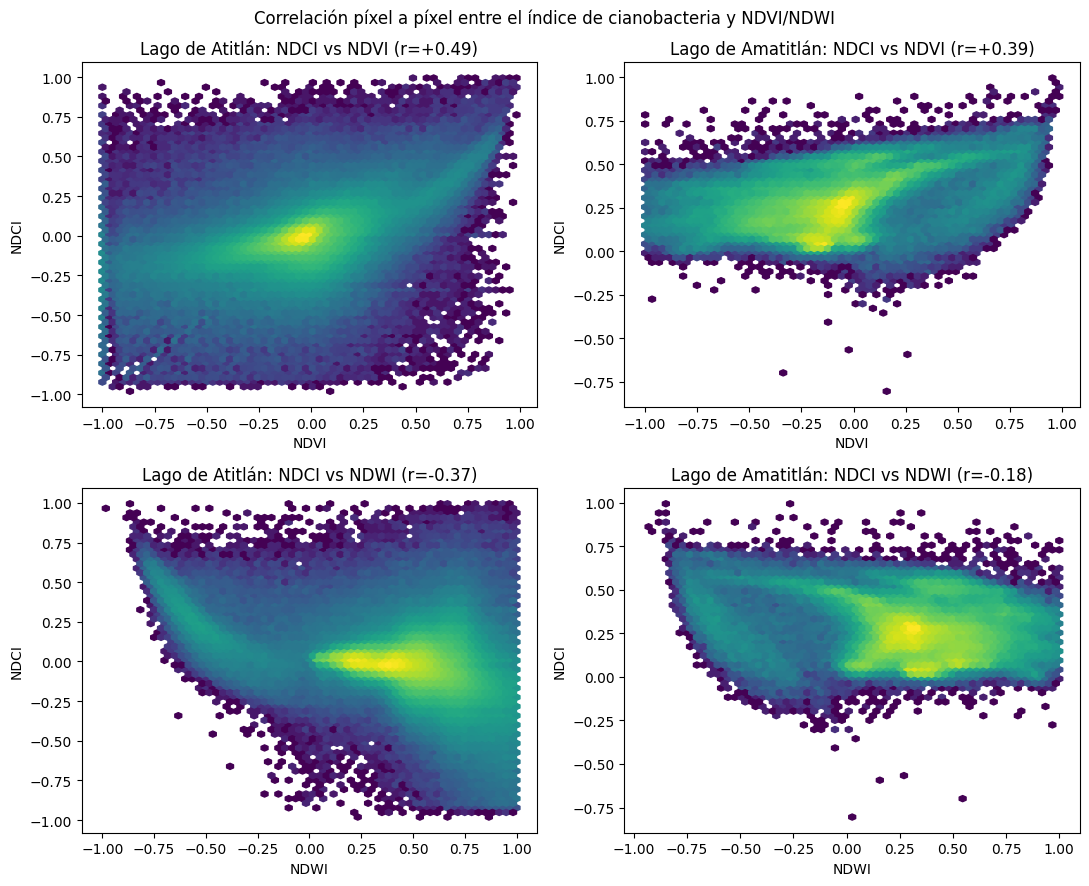

In [16]:
from scipy import stats

def puntos_pixel(lago):
    "Apila NDCI, NDVI y NDWI de todos los píxeles válidos del lago en las fechas confiables."
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        lago_m = s.read(1).astype(bool)
    fechas_conf = df[(df.lago==lago) & df.confiable].fecha_str.tolist()
    ndci_l, ndvi_l, ndwi_l = [], [], []
    for f in fechas_conf:
        with rasterio.open(ruta_indices(lago, f)) as s:
            ndci, ndvi, ndwi, val = s.read(1), s.read(4), s.read(5), s.read(7).astype(bool)
        # NDVI y NDWI fuera de [-1, 1] son el mismo artefacto de reflectancia casi nula
        # que ya se filtró para el NDCI (ver "Control de calidad" en el Ejercicio 3).
        sel = (lago_m & val & np.isfinite(ndci) & np.isfinite(ndvi) & np.isfinite(ndwi)
               & (np.abs(ndvi) <= 1) & (np.abs(ndwi) <= 1))
        ndci_l.append(ndci[sel]); ndvi_l.append(ndvi[sel]); ndwi_l.append(ndwi[sel])
    return np.concatenate(ndci_l), np.concatenate(ndvi_l), np.concatenate(ndwi_l)

pix = {lago: puntos_pixel(lago) for lago in LAGOS}

filas = []
for lago, (ndci, ndvi, ndwi) in pix.items():
    r_ndvi, p_ndvi = stats.pearsonr(ndci, ndvi)
    r_ndwi, p_ndwi = stats.pearsonr(ndci, ndwi)
    rho_ndvi, _ = stats.spearmanr(ndci, ndvi)
    rho_ndwi, _ = stats.spearmanr(ndci, ndwi)
    filas.append(dict(lago=lago, n_pixeles=len(ndci),
                       pearson_ndci_ndvi=r_ndvi, pearson_ndci_ndwi=r_ndwi,
                       spearman_ndci_ndvi=rho_ndvi, spearman_ndci_ndwi=rho_ndwi,
                       p_ndvi=p_ndvi, p_ndwi=p_ndwi))
corr_pixel = pd.DataFrame(filas).round(4)
display(corr_pixel)
corr_pixel.to_csv(DIR_RES / "correlacion_pixel.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for col, lago in enumerate(LAGOS):
    ndci, ndvi, ndwi = pix[lago]
    r_ndvi = corr_pixel.loc[corr_pixel.lago==lago, "pearson_ndci_ndvi"].iloc[0]
    r_ndwi = corr_pixel.loc[corr_pixel.lago==lago, "pearson_ndci_ndwi"].iloc[0]
    axes[0, col].hexbin(ndvi, ndci, gridsize=60, cmap="viridis", mincnt=1, bins="log")
    axes[0, col].set_title(f"{NOMBRE[lago]}: NDCI vs NDVI (r={r_ndvi:+.2f})")
    axes[0, col].set_xlabel("NDVI"); axes[0, col].set_ylabel("NDCI")
    axes[1, col].hexbin(ndwi, ndci, gridsize=60, cmap="viridis", mincnt=1, bins="log")
    axes[1, col].set_title(f"{NOMBRE[lago]}: NDCI vs NDWI (r={r_ndwi:+.2f})")
    axes[1, col].set_xlabel("NDWI"); axes[1, col].set_ylabel("NDCI")
fig.suptitle("Correlación píxel a píxel entre el índice de cianobacteria y NDVI/NDWI")
fig.tight_layout(); fig.savefig(DIR_FIG / "correlacion_pixel.png", dpi=150); plt.show()

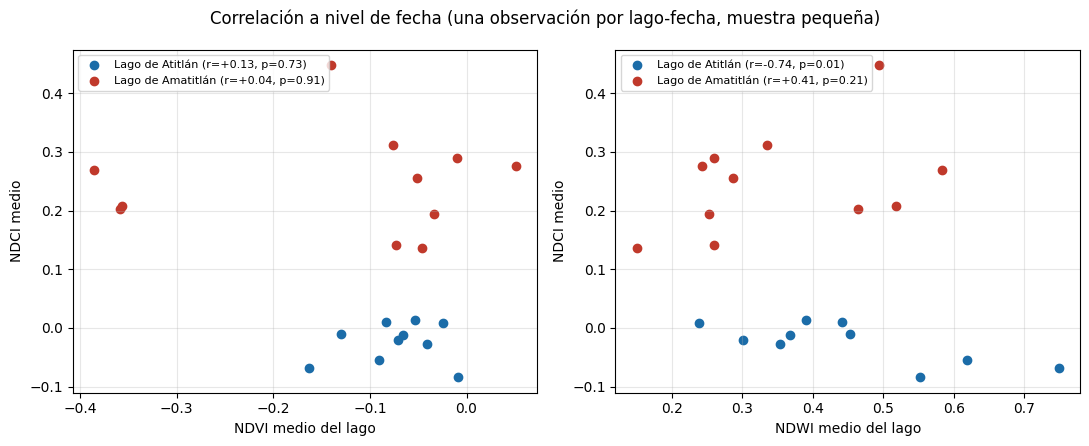

,lago,n_fechas,r_ndvi_fecha,p_ndvi_fecha,r_ndwi_fecha,p_ndwi_fecha
0,atitlan,10,0.1273,0.7261,-0.7442,0.0136
1,amatitlan,11,0.0382,0.9113,0.4111,0.2091


In [17]:
resumen_corr = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for lago in LAGOS:
    sub = df[(df.lago==lago) & df.confiable].dropna(subset=["ndvi_media","ndwi_media","ndci_media"])
    r1, p1 = stats.pearsonr(sub.ndvi_media, sub.ndci_media)
    r2, p2 = stats.pearsonr(sub.ndwi_media, sub.ndci_media)
    axes[0].scatter(sub.ndvi_media, sub.ndci_media, color=COLOR[lago],
                    label=f"{NOMBRE[lago]} (r={r1:+.2f}, p={p1:.2f})")
    axes[1].scatter(sub.ndwi_media, sub.ndci_media, color=COLOR[lago],
                    label=f"{NOMBRE[lago]} (r={r2:+.2f}, p={p2:.2f})")
    resumen_corr.append(dict(lago=lago, n_fechas=len(sub),
                              r_ndvi_fecha=r1, p_ndvi_fecha=p1,
                              r_ndwi_fecha=r2, p_ndwi_fecha=p2))
axes[0].set_xlabel("NDVI medio del lago"); axes[0].set_ylabel("NDCI medio")
axes[0].grid(alpha=.3); axes[0].legend(fontsize=8)
axes[1].set_xlabel("NDWI medio del lago"); axes[1].set_ylabel("NDCI medio")
axes[1].grid(alpha=.3); axes[1].legend(fontsize=8)
fig.suptitle("Correlación a nivel de fecha (una observación por lago-fecha, muestra pequeña)")
fig.tight_layout(); fig.savefig(DIR_FIG / "correlacion_fecha.png", dpi=150); plt.show()

resumen_corr = pd.DataFrame(resumen_corr).round(4)
display(resumen_corr)
resumen_corr.to_csv(DIR_RES / "correlacion_fecha.csv", index=False)

### 6.1 Interpretación de los hallazgos

**La relación esperada aparece con claridad a nivel de píxel, que es la evidencia más
confiable disponible aquí.** Con 2.48 millones de píxeles en Atitlán y 338 mil en
Amatitlán, el NDCI se correlaciona positivamente con el NDVI (r = +0.49 en Atitlán,
r = +0.39 en Amatitlán) y negativamente con el NDWI (r = −0.37 en Atitlán, r = −0.18 en
Amatitlán). El signo es el que predice la física del problema: un píxel con más
cianobacteria refleja más luz en el infrarrojo cercano relativo al rojo (sube el NDVI,
como si fuera vegetación) y se aleja del patrón típico de agua abierta (baja el NDWI). Las
correlaciones de Spearman —que no asumen una relación lineal— confirman la misma
dirección y una magnitud similar, así que no es un artefacto de valores extremos.

**La correlación es más fuerte con el NDVI que con el NDWI, y más fuerte en Atitlán que en
Amatitlán.** Que el NDVI capture mejor la señal tiene sentido: es el índice diseñado para
pigmento fotosintético, mientras que el NDWI reacciona a la presencia de agua libre en
general y puede mantenerse "acuático" incluso con una floración moderada. Que la relación
sea más fuerte en Atitlán es, en parte, un efecto de rango: al no haber floraciones
extendidas, casi toda la variación del NDCI en ese lago ocurre dentro del tramo bajo y
limpio del índice, donde la respuesta óptica es más lineal; en Amatitlán, con el lago
crónicamente afectado, buena parte de la superficie ya satura o se acerca a valores altos
de Chl-a, lo que comprime la relación.

**A nivel de fecha (n=10-11) el patrón es más débil e inestable, como es de esperar con
una muestra tan pequeña.** En Atitlán, la correlación NDCI-NDWI por fecha sí es negativa y
estadísticamente significativa (r = −0.74, p = 0.014), consistente con el resultado a
nivel de píxel; pero la correlación con NDVI no lo es (r = +0.13, p = 0.73). En Amatitlán
ninguna de las dos correlaciones por fecha es significativa, y el signo de NDCI-NDWI
incluso se invierte respecto al nivel de píxel (r = +0.41 por fecha frente a r = −0.18 por
píxel) — una discrepancia que apunta a que una sola fecha atípica (el 19 de junio de 2026,
con la floración más extensa de toda la serie) está dominando una regresión de solo 11
puntos, y no a que la relación física haya cambiado de sentido.

**Significado ambiental.** La correlación positiva con el NDVI y negativa con el NDWI
confirma, con una fuente de datos independiente del propio cálculo del NDCI, que lo que se
está midiendo es consistente con una floración real: agua que ópticamente se parece cada
vez menos a agua limpia y cada vez más a una superficie vegetal. Para la gestión de ambos
lagos esto significa que el NDVI puede usarse como una señal de apoyo barata (no requiere
el cálculo completo del NDCI) para marcar zonas sospechosas antes de un muestreo de campo,
mientras que caídas fuertes y localizadas del NDWI son un buen indicador de que una zona
del lago dejó de comportarse como agua abierta.

**Limitaciones.** La correlación a nivel de píxel agrupa todas las fechas y no controla
por fecha ni por posición, así que puede reflejar en parte diferencias sistemáticas entre
zonas del lago (por ejemplo profundidad o cercanía a la orilla) que también se
correlacionan con NDVI y NDWI por razones ajenas a la cianobacteria. Además, r ≈ 0.4-0.5
es una asociación moderada, no una relación determinista: el NDVI y el NDWI no sustituyen
al NDCI calibrado para cianobacteria, y deben leerse como una señal de apoyo, no como el
índice principal.